In [111]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

DATA_DIR = BASE_DIR / "data" / "processed"
REPORT_DIR = BASE_DIR / "reports"
CHART_DIR = REPORT_DIR / "charts"
CHART_DIR.mkdir(
    parents=True,
    exist_ok=True
)

## Task 1: VaR & CVaR

In [112]:
import pandas as pd
import numpy as np

nav = pd.read_csv(DATA_DIR / "02_nav_history_clean.csv")
funds = pd.read_csv(DATA_DIR / "01_fund_master_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change(fill_method=None)
)

results = []

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(
        returns,
        5
    )

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_df = var_df.merge(
    funds[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

var_df = var_df[
    [
        "amfi_code",
        "scheme_name",
        "var_95",
        "cvar_95"
    ]
]

var_df.to_csv(
    REPORT_DIR / "var_cvar_report.csv",
    index=False
)

print("Saved:")
print( REPORT_DIR / "var_cvar_report.csv")

var_df.head()

Saved:
/Users/shreyasinha/Desktop/bluestock_mf_capstone/reports/var_cvar_report.csv


,amfi_code,scheme_name,var_95,cvar_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.037824,-0.084658
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.010334,-0.031396
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.032199,-0.122863
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.041529,-0.111292
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.064542,-0.128699


## Task 2: Rolling 90-Day Sharpe Ratio

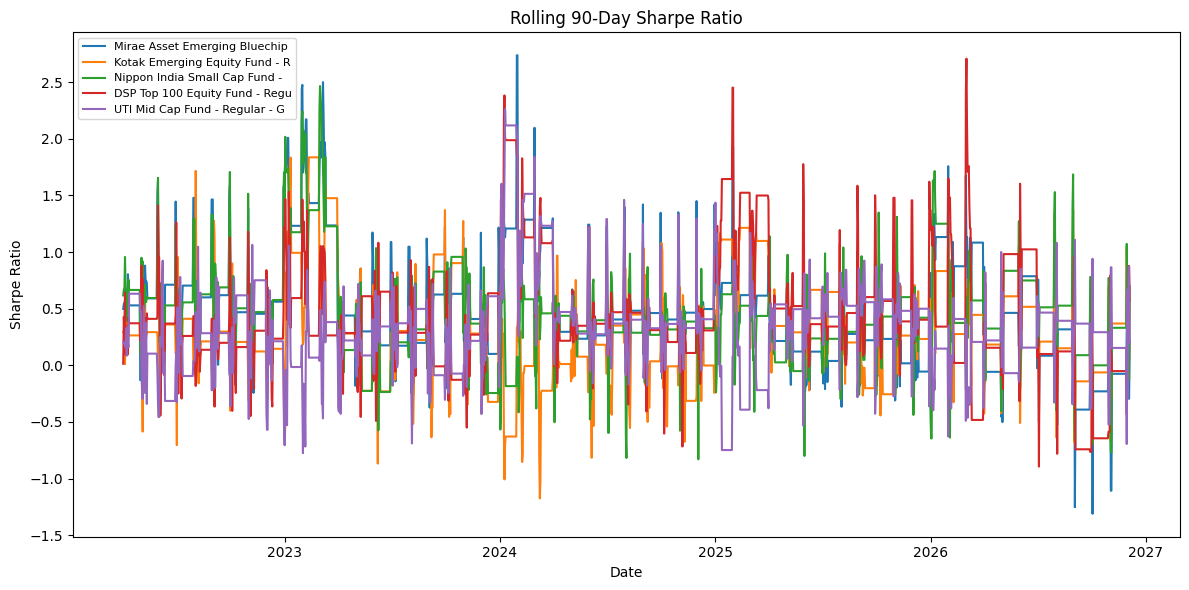

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv(
    DATA_DIR / "02_nav_history_clean.csv"
)

perf = pd.read_csv(
    DATA_DIR / "07_performance_clean.csv"
)

nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change(fill_method=None)
)

top_funds = (
    perf.sort_values(
        "aum_crore",
        ascending=False
    )
    .head(5)["amfi_code"]
    .tolist()
)

plt.figure(figsize=(12,6))

for fund in top_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    sharpe = (
        temp["return"]
        .rolling(90)
        .mean()
        /
        temp["return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    name = perf.loc[
        perf["amfi_code"] == fund,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        temp["date"],
        sharpe,
        label=name[:30]
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend(
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Task 3: Investor Cohort Analysis

In [114]:
import pandas as pd

txn = pd.read_csv(
    DATA_DIR / "08_transactions_clean.csv"
)

funds = pd.read_csv(
    DATA_DIR / "01_fund_master_clean.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

first_txn = (
    txn.groupby("investor_id")["transaction_date"]
       .min()
       .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

txn = txn.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

fund_pref = (
    txn.groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(
        name="transactions"
    )
)

top_funds = (
    fund_pref.sort_values(
        ["cohort_year", "transactions"],
        ascending=[True, False]
    )
    .drop_duplicates(
        subset=["cohort_year"]
    )
)

sip_txn = txn[
    txn["transaction_type"] == "SIP"
]

avg_sip = (
    sip_txn.groupby("cohort_year")
    ["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

total_inv = (
    txn.groupby("cohort_year")
    ["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

summary = avg_sip.merge(
    total_inv,
    on="cohort_year"
)

summary = summary.merge(
    top_funds[
        ["cohort_year", "amfi_code"]
    ],
    on="cohort_year",
    how="left"
)

summary = summary.merge(
    funds[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

summary.to_csv(
    REPORT_DIR / "cohort_analysis.csv",
    index=False
)

print("Saved:")
print(REPORT_DIR / "cohort_analysis.csv")



Saved:
/Users/shreyasinha/Desktop/bluestock_mf_capstone/reports/cohort_analysis.csv


## Task 4: SIP Continuity Analysis

In [115]:
import pandas as pd

txn = pd.read_csv(
    DATA_DIR / "08_transactions_clean.csv"
)

txn = txn[
    txn["transaction_type"] == "SIP"
].copy()

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn = txn.sort_values(
    ["investor_id",
     "transaction_date"]
)

txn["gap_days"] = (
    txn.groupby(
        "investor_id"
    )["transaction_date"]
    .diff()
    .dt.days
)

counts = (
    txn.groupby(
        "investor_id"
    )
    .size()
)

eligible = (
    counts[
        counts >= 6
    ]
    .index
)

sip = txn[
    txn["investor_id"]
    .isin(eligible)
]

continuity = (
    sip.groupby(
        "investor_id"
    )
    .agg(
        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )
    .reset_index()
)

continuity["status"] = np.where(
    continuity["avg_gap_days"] > 35,
    "At-Risk",
    "Healthy"
)

continuity.to_csv(
    REPORT_DIR / "sip_continuity.csv",
    index=False
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


## Task 6: Sector Concentration (HHI)

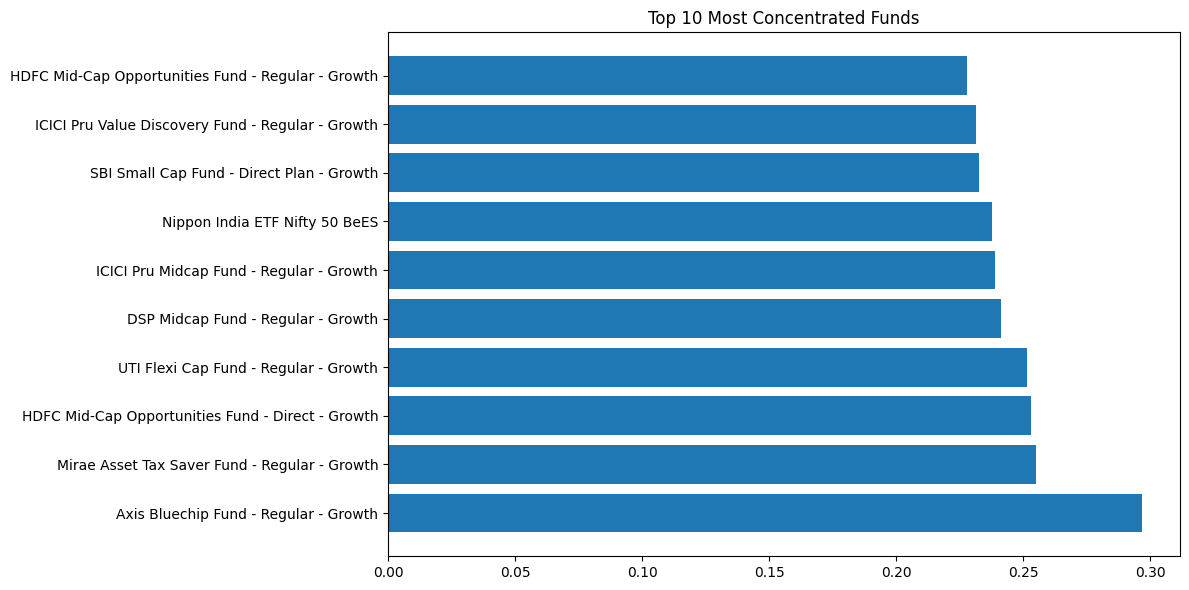

,amfi_code,HHI,scheme_name
0,100016,0.180588,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.180042,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.222727,ABSL Small Cap Fund - Regular - Growth
4,102885,0.180712,UTI Nifty 50 Index Fund - Regular - Growth


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

holdings = pd.read_csv(
    DATA_DIR / "09_holdings_clean.csv"
)

funds = pd.read_csv(
    DATA_DIR / "01_fund_master_clean.csv"
)

hhi = (
    holdings.groupby(
        ["amfi_code",
         "sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

hhi["sq"] = (
    hhi["weight_pct"] / 100
) ** 2

sector_hhi = (
    hhi.groupby(
        "amfi_code"
    )["sq"]
    .sum()
    .reset_index()
)

sector_hhi.rename(
    columns={
        "sq":"HHI"
    },
    inplace=True
)

sector_hhi = sector_hhi.merge(
    funds[
        ["amfi_code",
         "scheme_name"]
    ],
    on="amfi_code"
)

sector_hhi.to_csv(
    REPORT_DIR / "sector_hhi.csv",
    index=False
)

top10 = sector_hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

plt.figure(
    figsize=(12,6)
)

plt.barh(
    top10["scheme_name"],
    top10["HHI"]
)

plt.title(
    "Top 10 Most Concentrated Funds"
)

plt.tight_layout()

plt.savefig(
    CHART_DIR / "sector_hhi_chart.png",
    dpi=300
)

plt.show()

sector_hhi.head()

# Advanced Analytics Summary

## Key Insights

1. Historical VaR and CVaR were calculated for all funds using daily NAV returns at the 95% confidence level.

2. Rolling 90-Day Sharpe Ratios identified periods of strong and weak risk-adjusted performance across major funds.

3. Investor cohort analysis revealed differences in investment behaviour between 2024 and 2025 cohorts.

4. SIP continuity analysis identified investors with average transaction gaps greater than 35 days as At-Risk.

5. Sector concentration analysis using HHI highlighted funds with highly concentrated portfolios and higher concentration risk.